# IRKGL16 vs explicit symplectic integrators (6-Body Solar System)

Running the code cells below will compute and automatically generate the following figures:

-  **From Section 5.3.1**:
    - **Figure 3(a)**, saved as **`Fig7.pdf`**



- **From Section 5.3.2**

    - **Figure 7**, saved as **`Fig14.pdf`**
    - **Figure 18(a)**, saved as **`Fig15.pdf`**
    - **Figure 18(b)**, saved as **`Fig16.pdf`**


<ul id="top">
    <li><a href="#Loading-packages-and-functions">Loading packages and functions</a></li>
    <li><a href="#Definition-of-the-N-body-problem">Definition of the N-body problem</a></li>
    <li><a href="#IRKGL16-integrations">IRKGL16-integrations</a></li>
    <li><a href="#2nd-order-explicit-symplectic-integrations">2nd order explicit symplectic integrations</a></li>
    <li><a href="#Benchmarks-diagrams">Benchmarks diagrams</a></li>
    <ul>
        <li><a href="#Work-precision-diagrams">Work-precision-diagrams</a></li>
        <li><a href="#Select-integration-with-same-CPU-time">Select integration with same CPU time</a></li>
        <li><a href="#Error-in-Energy">Error in Energy</a></li>
        <li><a href="#Error-in-Solution">Error in Solution</a></li>
    </ul>
    <li><a href="#Benchmarks-diagrams  (Splitting simd)">Benchmarks diagrams  (Splitting simd)</a></li>
</ul>

## Loading packages and functions

In [1]:
using LinearAlgebra
using Plots
using LaTeXStrings
using BenchmarkTools
using IRKGaussLegendre
using SIMD

In [2]:
PATH_Splitting="../../"
include(string(PATH_Splitting,"/src/SplittingMethods.jl"))
using .SplittingMethods  

In [3]:
Base.@boundscheck false
pkgversion(IRKGaussLegendre) # must be v"0.2.13" or greater

v"0.2.13"

### Utils

In [4]:
mutable struct tsolutions_IRKGL16
    dts
    sols
    retcodes
    iters
    cpus
    fcns
    MaxΔHglobal
    MaxΔHlocal
    wcpu
    cpu_idx
end

function run_many_IRKGL16(alg, prob, ddt0, HAM; wcpu=true)

    u0=prob.u0
    parms=prob.p
    
    u0_B=BigFloat.(u0)
    parms_B=BigFloat.(parms)
    
    cpus=zero(ddt0)
    fcns=zero(ddt0)
    iters=zero(ddt0)
    retcodes=[true for k in ddt0]
    MaxΔHglobal=[0. for i in ddt0]
    MaxΔHlocal=[0. for i in ddt0]
    
    sols=Array{IRKGaussLegendre.ODESolution}(undef,length(ddt0))
    H0=HAM(u0_B,parms_B)
    
    for i in 1:length(ddt0)
        
        print(",",ddt0[i])    
        dt0=ddt0[i]
        
        sols[i]=solve(prob,alg,dt=dt0, adaptive=false)
        if sols[i].retcode==ReturnCode.Success
           iters[i]=sols[i].stats.nfpiter
           fcns[i]=iters[i]*8
        else
           retcodes[i]=false
           iters[i]=Inf
           fcns[i]=Inf
        end

        H = [HAM(BigFloat.(u),parms_B) for u in sols[i].u]
        ΔH0 = @. Float64(abs(H/H0-1))
        H_lerr = @. Float64(abs((H[2:end] / H[1:end-1]) - 1))
        MaxΔHglobal[i]=maximum(ΔH0)
        MaxΔHlocal[i]=maximum(H_lerr)

        if wcpu
            solve(prob,alg, dt=dt0, adaptive=false, save_everystep = false)
            cpus[i]= @belapsed solve($prob,$alg, dt=$dt0, adaptive=false, save_everystep = false)
        end
        
    end

    println("")
    return tsolutions_IRKGL16(ddt0, sols,retcodes,iters,cpus,fcns,MaxΔHglobal,MaxΔHlocal,wcpu,-1)

end  

run_many_IRKGL16 (generic function with 1 method)

In [5]:
mutable struct tsolutions_Splitting
   s
   r
   alg
   dts
   sols
   retcodes
  # nflowsH3
   cpus
   fcns 
   MaxΔHglobal
   MaxΔHlocal
   wcpu 
   cpu_idx
end

function run_many_Splitting(s, r, alg, prob, ddt0, HAM; wcpu=true)
    
    u0=prob.u0
    parms=prob.p
    
    u0_B=BigFloat.(u0)
    parms_B=BigFloat.(parms)
    
    cpus=zero(ddt0)
    fcns=zero(ddt0)
    #nflowsH3=similar(ddt0)
    retcodes=[true for k in ddt0]
    MaxΔHglobal=[0. for i in ddt0]
    MaxΔHlocal=[0. for i in ddt0]

    sols=Array{SplittingMethods.ODESolution}(undef,length(ddt0))
    H0=HAM(u0_B, parms_B)

    for i in 1:length(ddt0)

        print(",",ddt0[i])
        dt0=ddt0[i]  

        # save_everystep=true
        m0=1
        sols[i]=solver_Splitting(prob, alg, dt=dt0)

        if sols[i].success
           fcns[i]=sols[i].stats.naccept*s 
        else
           retcodes[i]=false
           fcns[i]=Inf
        end

        H = [HAM(BigFloat.(u),parms_B) for u in sols[i].u]
        ΔH0 = @. Float64(abs(H/H0-1))
        H_lerr = @. Float64(abs((H[2:end] / H[1:end-1]) - 1))
        MaxΔHglobal[i]=maximum(ΔH0)
        MaxΔHlocal[i]=maximum(H_lerr)

        if wcpu
            solver_Splitting(prob, alg, dt=dt0, save_everystep=false)
            cpus[i]=@belapsed solver_Splitting($prob, $alg, dt=$dt0, save_everystep=false)
        end
    end

    println("")
    return tsolutions_Splitting(s, r, alg, ddt0, sols,retcodes,cpus,fcns, MaxΔHglobal,MaxΔHlocal,wcpu,-1)
 
end

run_many_Splitting (generic function with 1 method)

In [6]:
function find_index_ge_cpu(lookup_value, v)

   idx=0
   for k in length(v):-1:1

       if v[k]>=lookup_value
          idx=k
          break
       end

   end

   return idx

end

function compute_index_ge_cpu!(indexes, lookup_value, manysols)

   for i  in 1:length(manysols)

      if manysols[i].wcpu  
         idx=find_index_ge_cpu(lookup_value, manysols[i].cpus)
         push!(indexes,idx)
      else
         push!(indexes,-1)
      end
   end

   return nothing

end

function lcm_floats_vector(numbers::Vector{Float64})
   # Convert the numbers to rationals
   rationals = rationalize.(numbers)
   # Compute the LCM iteratively
   lcm_rationals = reduce(lcm, rationals)
   return lcm_rationals
end

lcm_floats_vector (generic function with 1 method)

##### <a href="#top">Back to the top</a>

## Definition of the N-body problem

In Nbody.jl below, the following functions are defined: NbodyEnergy(u,Gm), NbodyODE!(du,u,Gm,t), and NbodyODE1!(du,u,Gm,t), where

\begin{equation*}
u = 
\left(\begin{matrix}
q_1  & v_1\\
\vdots & \vdots \\
q_N  & v_N
\end{matrix}
\right) \in \mathbb{R}^{2 \times 3\times N}, \quad
Gm = (G\,  m_1, \ldots,G\,  m_N) \in \mathbb{R}^N.
\end{equation*}

The energy, as a function of the positions $q_1,\ldots,q_N \in \mathbb{R}^3$ and the velocities $v_1,\ldots,v_N \in \mathbb{R}^3$ of the $N$ bodies is:
\begin{equation*}
\begin{split}
\mathrm{Energy}(q_1,\ldots,q_N,v_1,\ldots,v_N) = 
\frac12 \sum_{i=1}^{N} m_i \, \|v_i\|^2
- G \sum_{1\leq i < j \leq N} \frac{m_i m_j}{\|q_i-q_j\|}.
\end{split}
\end{equation*}


The ODE system of the N-body problem,
as a function of the positions $q_1,\ldots,q_N \in \mathbb{R}^3$ and the velocities $v_1,\ldots,v_N \in \mathbb{R}^3$ of the $N$ bodies is:
\begin{equation*}
\begin{split}
\frac{d}{dt} q_i &= v_i, \\
\frac{d}{dt} v_i &= G\, 
\sum_{j \neq i} \frac{m_j}{\|q_j-q_i\|^3}\,
(q_j-q_i).
\end{split}
\end{equation*}
This system of ODEs can be writen in compact form as
\begin{equation*}
\frac{d u}{dt} = f(t,u,Gm)
\end{equation*}




In [7]:
function NbodyEnergy(u,Gm)
     N = length(Gm)
     zerouel = zero(eltype(u))
     T = zerouel
     U = zerouel
     for i in 1:N
        qi = u[:,i,1]
        vi = u[:,i,2]
        Gmi = Gm[i]
        T += Gmi*(vi[1]*vi[1]+vi[2]*vi[2]+vi[3]*vi[3])
        for j in (i+1):N
           qj = u[:,j,1]
           Gmj = Gm[j]
           qij = qi - qj
           U -= Gmi*Gmj/norm(qij)
        end
     end
    1/2*T + U
end


function NbodyODE!(F,u,Gm,t)
   N = length(Gm)
   for i in 1:N
      for k in 1:3
          F[k, i, 2] = 0
      end
   end
   for i in 1:N
      xi = u[1,i,1]
      yi = u[2,i,1]
      zi = u[3,i,1]
      Gmi = Gm[i]
      for j in i+1:N
          xij = xi - u[1,j,1]
          yij = yi - u[2,j,1]
          zij = zi - u[3,j,1]
          Gmj = Gm[j]
          dotij = (xij*xij+yij*yij+zij*zij)
          auxij = 1/(sqrt(dotij)*dotij)
          Gmjauxij = Gmj*auxij
          F[1,i,2] -= Gmjauxij*xij
          F[2,i,2] -= Gmjauxij*yij
          F[3,i,2] -= Gmjauxij*zij
          Gmiauxij = Gmi*auxij
          F[1,j,2] += Gmiauxij*xij
          F[2,j,2] += Gmiauxij*yij
          F[3,j,2] += Gmiauxij*zij
      end
   end
   for i in 1:3, j in 1:N
      F[i,j,1] = u[i,j,2]
   end
  return nothing
end


function N6bodyODE_simd!(F,u,Gm,t)

@inbounds  begin

   x1,x2,x3,x4,x5,x6 = u[1],u[4],u[7],u[10],u[13],u[16]
   y1,y2,y3,y4,y5,y6 = u[2],u[5],u[8],u[11],u[14],u[17]
   z1,z2,z3,z4,z5,z6 = u[3],u[6],u[9],u[12],u[15],u[18]
   l=one(x1)
   o=zero(x1) 


   # Interactions
   xi=Vec(x1,x1,x1,x1,x1, x2,x2,x2,x2, x3,x3,x3, x4,x4, x5, l) 
   yi=Vec(y1,y1,y1,y1,y1, y2,y2,y2,y2, y3,y3,y3, y4,y4, y5, l) 
   zi=Vec(z1,z1,z1,z1,z1, z2,z2,z2,z2, z3,z3,z3, z4,z4, z5, l) 
   xj=Vec(x2,x3,x4,x5,x6, x3,x4,x5,x6, x4,x5,x6, x5,x6, x6, o)
   yj=Vec(y2,y3,y4,y5,y6, y3,y4,y5,y6, y4,y5,y6, y5,y6, y6, o)
   zj=Vec(z2,z3,z4,z5,z6, z3,z4,z5,z6, z4,z5,z6, z5,z6, z6, o)
   xij=xi-xj
   yij=yi-yj
   zij=zi-zj
   Gmi=Vec(Gm[1],Gm[1],Gm[1],Gm[1],Gm[1],
           Gm[2],Gm[2],Gm[2],Gm[2],
           Gm[3],Gm[3],Gm[3],
           Gm[4],Gm[4],
           Gm[5], o)
   Gmj=Vec(Gm[2],Gm[3],Gm[4],Gm[5],Gm[6],
           Gm[3],Gm[4],Gm[5],Gm[6],
           Gm[4],Gm[5],Gm[6],
           Gm[5],Gm[6],
           Gm[6], o)
   dotij = (xij*xij+yij*yij+zij*zij)
   auxij = 1/(sqrt(dotij)*dotij)
   Gmjauxij = -Gmj*auxij
   Gmiauxij = Gmi*auxij
   sxj=Gmjauxij*xij
   syj=Gmjauxij*yij
   szj=Gmjauxij*zij
   sxi=Gmiauxij*xij
   syi=Gmiauxij*yij
   szi=Gmiauxij*zij

        
   S1 = Vec(sxj[1],syj[1],szj[1], sxj[6],syj[6],szj[6], sxj[10],syj[10],szj[10], sxj[13],syj[13],szj[13], sxj[15],syj[15],szj[15],  sxi[5],syi[5],szi[5])
   S2 = Vec(sxj[2],syj[2],szj[2], sxj[7],syj[7],szj[7], sxj[11],syj[11],szj[11], sxj[14],syj[14],szj[14], sxi[4],syi[4],szi[4],     sxi[9],syi[9],szi[9])
   S3 = Vec(sxj[3],syj[3],szj[3], sxj[8],syj[8],szj[8], sxj[12],syj[12],szj[12], sxi[3],syi[3],szi[3],    sxi[8],syi[8],szi[8],     sxi[12],syi[12],szi[12])
   S4 = Vec(sxj[4],syj[4],szj[4], sxj[9],syj[9],szj[9], sxi[2],syi[2],szi[2],    sxi[7],syi[7],szi[7],    sxi[11],syi[11],szi[11],  sxi[14],syi[14],szi[14])
   S5 = Vec(sxj[5],syj[5],szj[5], sxi[1],syi[1],szi[1], sxi[6],syi[6],szi[6],    sxi[10],syi[10],szi[10], sxi[13],syi[13],szi[13],  sxi[15],syi[15],szi[15])
   S = S1 + S2 + S3 + S4 + S5

   vstore(S, F, 19)
   for k in 1:18
       F[k]=u[k+18]
   end

        
  end     

  return nothing
    
end



N6bodyODE_simd! (generic function with 1 method)

In [8]:
function NbodyBarycenter(u,Gm)
     N = length(Gm)
     dim = size(u,1)
     A = zeros(dim)
     B = zeros(dim)
     for i in 1:N
        qi = u[:,i,1]
        vi = u[:,i,2]
        Gmi = Gm[i]
        A += Gmi*qi
        B += Gmi*vi
     end
     return A, B
end



function Initial6Body(T=Float64)

   # DE430
   N=6

   #u_, Gm_, bodylist_ = Initial10Body()
   N_=10
   GmMoon = 0.109318945074237400e-10
   GmEarth = 0.888769244512563400e-9
   Gm_ = [0.295912208285591100e-3, 0.491248045036476000e-10,
         0.724345233264412000e-9,
         GmEarth + GmMoon,
         0.954954869555077000e-10, 0.282534584083387000e-6,
         0.845970607324503000e-7, 0.129202482578296000e-7,
         0.152435734788511000e-7, 0.217844105197418000e-11]

   q = [0.00450250878464055477, 0.00076707642709100705,0.00026605791776697764,
        0.36176271656028195477, -0.09078197215676599295,-0.08571497256275117236,
        0.61275194083507215477, -0.34836536903362219295,-0.19527828667594382236,
        0.12051741410138465477, -0.92583847476914859295,-0.40154022645315222236,
       -0.11018607714879824523, -1.32759945030298299295,-0.60588914048429142236,
       -5.37970676855393644523, -0.83048132656339789295,-0.22482887442656542236,
        7.89439068290953155477, 4.59647805517127300705, 1.55869584283189997764,
       -18.26540225387235944523, -1.16195541867586999295,-0.25010605772133802236,
       -16.05503578023336944523, -23.94219155985470899295,-9.40015796880239402236,
       -30.48331376718383944523, -0.87240555684104999295, 8.91157617249954997764]
  
    v = [-0.00000035174953607552, 0.00000517762640983341,0.00000222910217891203,
          0.00336749397200575848, 0.02489452055768343341,0.01294630040970409203,
          0.01095206842352823448, 0.01561768426786768341, 0.00633110570297786403,
          0.01681126830978379448, 0.00174830923073434441, 0.00075820289738312913,
          0.01448165305704756448, 0.00024246307683646861, -0.00028152072792433877,
          0.00109201259423733748, -0.00651811661280738459,-0.00282078276229867897,
         -0.00321755651650091552, 0.00433581034174662541, 0.00192864631686015503,
          0.00022119039101561468, -0.00376247500810884459,-0.00165101502742994997,
          0.00264276984798005548, -0.00149831255054097759,-0.00067904196080291327,
          0.00032220737349778078, -0.00314357639364532859,-0.00107794975959731297]

 
    qq = copy(q)
    vv = copy(v)
  
    q0 = reshape(qq,3,:)
    v0 = reshape(vv,3,:)

    q0bar = [sum(Gm_ .* q0[j,:])/sum(Gm_) for j in 1:3]
    v0bar = [sum(Gm_ .* v0[j,:])/sum(Gm_) for j in 1:3]
    q0 = q0 .- q0bar
    v0 = v0 .- v0bar

    u_ = Array{T}(undef,3,N_,2)
    u_[:,:,2] = v0
    u_[:,:,1] = q0
 
   # Recalcular datos del Sistema, tomando el Sistema Solar interior como una masa puntual en su centro de masas 

 
   q0 = zeros(3)
   v0 = zeros(3)
   Gm0 = 0.
   for i in 1:5
      Gmi = Gm_[i]
      qi = u_[:,i,1]
      vi = u_[:,i,2]
      q0 += Gmi*qi
      v0 += Gmi*vi
      Gm0 += Gmi
   end
   q0 /= Gm0
   v0 /= Gm0
    

   u0 = Array{T}(undef,3,N,2)   
   u0[:,1,1] = q0
   u0[:,1,2] = v0   
   u0[:,2:end,1] = u_[:,6:10,1]
   u0[:,2:end,2] = u_[:,6:10,2]  
   
   Gm = [Gm0; Gm_[6:10]]   
   bodylist = ["Sun" "Jupiter" "Saturn" "Uranus"  "Neptune" "Pluto"]

   return u0, Gm, bodylist


end

Initial6Body (generic function with 2 methods)

In [9]:
function flowH1Nbody!(uj,ej,h,Gm)

   N = length(Gm)

   for i in 1:3, j in 1:N
      hi_ = uj[i,j,1]
      delta = ej[i,j,1] + h*uj[i,j,2]
      hi = hi_ + delta
      delta_ = hi - hi_
      uj[i,j,1] = hi
      ej[i,j,1] = delta - delta_
   end

  return nothing
end



function flowH2Nbody!(uj,ej,h,Gm)

   N = length(Gm)
   for i in 1:N
      xi = uj[1,i,1]
      yi = uj[2,i,1]
      zi = uj[3,i,1]
      Gmi = h*Gm[i]
      for j in i+1:N
          xij = xi - uj[1,j,1]
          yij = yi - uj[2,j,1]
          zij = zi - uj[3,j,1]
          Gmj = h*Gm[j]
          dotij = (xij*xij+yij*yij+zij*zij)
          auxij = 1/(sqrt(dotij)*dotij)
          Gmjauxij = Gmj*auxij
          ej[1,i,2] -= Gmjauxij*xij
          ej[2,i,2] -= Gmjauxij*yij
          ej[3,i,2] -= Gmjauxij*zij
          Gmiauxij = Gmi*auxij
          ej[1,j,2] += Gmiauxij*xij
          ej[2,j,2] += Gmiauxij*yij
          ej[3,j,2] += Gmiauxij*zij
      end
   end
   for i in eachindex(uj)
      hi_ = uj[i]
      delta = ej[i]
      hi = hi_ + delta
      delta_ = hi - hi_
      uj[i] = hi
      ej[i] = delta - delta_
   end 
  return nothing

end

flowH2Nbody! (generic function with 1 method)

In [10]:
function flowH1Nbody_simd!(uj,ej,h,Gm)

   index1=1:18
   index2=19:36
   nd=18
    
   @inbounds begin
        
      for i in index1
          hi_ = uj[i]
          delta = ej[i]+h*uj[nd+i]
          hi = hi_ + delta
          delta_ = hi - hi_
          uj[i] = hi
          ej[i] = delta - delta_
      end 

   end     
  return nothing
end



function flowH2Nbody_simd!(uj,ej,h,Gm)

   nd=18
   x1,x2,x3,x4,x5,x6 = uj[1],uj[4],uj[7],uj[10],uj[13],uj[16]
   y1,y2,y3,y4,y5,y6 = uj[2],uj[5],uj[8],uj[11],uj[14],uj[17]
   z1,z2,z3,z4,z5,z6 = uj[3],uj[6],uj[9],uj[12],uj[15],uj[18]
   ex1,ex2,ex3,ex4,ex5,ex6 = ej[nd+1],ej[nd+4],ej[nd+7],ej[nd+10],ej[nd+13],ej[nd+16]
   ey1,ey2,ey3,ey4,ey5,ey6 = ej[nd+2],ej[nd+5],ej[nd+8],ej[nd+11],ej[nd+14],ej[nd+17]
   ez1,ez2,ez3,ez4,ez5,ez6 = ej[nd+3],ej[nd+6],ej[nd+9],ej[nd+12],ej[nd+15],ej[nd+18] 

   l=one(x1)
   o=zero(x1) 

   # Interactions
   xi=Vec(x1,x1,x1,x1,x1, x2,x2,x2,x2, x3,x3,x3, x4,x4, x5, l) 
   yi=Vec(y1,y1,y1,y1,y1, y2,y2,y2,y2, y3,y3,y3, y4,y4, y5, l) 
   zi=Vec(z1,z1,z1,z1,z1, z2,z2,z2,z2, z3,z3,z3, z4,z4, z5, l)
  
   xj=Vec(x2,x3,x4,x5,x6, x3,x4,x5,x6, x4,x5,x6, x5,x6, x6, o)
   yj=Vec(y2,y3,y4,y5,y6, y3,y4,y5,y6, y4,y5,y6, y5,y6, y6, o)
   zj=Vec(z2,z3,z4,z5,z6, z3,z4,z5,z6, z4,z5,z6, z5,z6, z6, o)


   xij=xi-xj
   yij=yi-yj
   zij=zi-zj

   Gmi=h*Vec(Gm[1],Gm[1],Gm[1],Gm[1],Gm[1],
           Gm[2],Gm[2],Gm[2],Gm[2],
           Gm[3],Gm[3],Gm[3],
           Gm[4],Gm[4],
           Gm[5], o)
   Gmj=h*Vec(Gm[2],Gm[3],Gm[4],Gm[5],Gm[6],
           Gm[3],Gm[4],Gm[5],Gm[6],
           Gm[4],Gm[5],Gm[6],
           Gm[5],Gm[6],
           Gm[6], o)

   dotij = (xij*xij+yij*yij+zij*zij)
   auxij = 1/(sqrt(dotij)*dotij)
   Gmjauxij = -Gmj*auxij
   Gmiauxij = Gmi*auxij
   sxj=Gmjauxij*xij   
   syj=Gmjauxij*yij   
   szj=Gmjauxij*zij   
   sxi=Gmiauxij*xij   
   syi=Gmiauxij*yij   
   szi=Gmiauxij*zij   

   S1 = Vec(sxj[1],syj[1],szj[1], sxj[6],syj[6],szj[6], sxj[10],syj[10],szj[10], sxj[13],syj[13],szj[13], sxj[15],syj[15],szj[15],  sxi[5],syi[5],szi[5])
   S2 = Vec(sxj[2],syj[2],szj[2], sxj[7],syj[7],szj[7], sxj[11],syj[11],szj[11], sxj[14],syj[14],szj[14], sxi[4],syi[4],szi[4],     sxi[9],syi[9],szi[9])
   S3 = Vec(sxj[3],syj[3],szj[3], sxj[8],syj[8],szj[8], sxj[12],syj[12],szj[12], sxi[3],syi[3],szi[3],    sxi[8],syi[8],szi[8],     sxi[12],syi[12],szi[12])
   S4 = Vec(sxj[4],syj[4],szj[4], sxj[9],syj[9],szj[9], sxi[2],syi[2],szi[2],    sxi[7],syi[7],szi[7],    sxi[11],syi[11],szi[11],  sxi[14],syi[14],szi[14])
   S5 = Vec(sxj[5],syj[5],szj[5], sxi[1],syi[1],szi[1], sxi[6],syi[6],szi[6],    sxi[10],syi[10],szi[10], sxi[13],syi[13],szi[13],  sxi[15],syi[15],szi[15])
   Se = Vec(ex1,ey1,ez1,          ex2,ey2,ez2,          ex3,ey3,ez3,             ex4,ey4,ez4,             ex5,ey5,ez5,              ex6,ey6,ez6)
   S =  S1 + S2 + S3 + S4 + S5 + Se

   vstore(S, ej, 19)

   #println(ej[19:end]) 
    
   for i in eachindex(uj)
      hi_ = uj[i]
      delta = ej[i]
      hi = hi_ + delta
      delta_ = hi - hi_
      uj[i] = hi
      ej[i] = delta - delta_
   end 
   
   return nothing

end


function NbodyEnergy_array(u,Gm)

     N = length(Gm)
     dim = 3
     nd =  18   # length_u/2 
    
     zerouel = zero(eltype(u))
     T = zerouel
     U = zerouel
    
     for i in 1:N
        iq = (i-1)*dim
        iv = nd+iq 
        qi = u[iq+1:iq+3]
        vi = u[iv+1:iv+3]
        Gmi = Gm[i]
        T += Gmi*(vi[1]*vi[1]+vi[2]*vi[2]+vi[3]*vi[3])

        for j in (i+1):N
             jq  = (j-1)*dim
             jv  = nd+jq   
             qj = u[jq+1:jq+3]
             Gmj = Gm[j]
             qij = qi - qj
             U -= Gmi*Gmj/norm(qij)
          end     
     end
    1/2*T + U
    
end



NbodyEnergy_array (generic function with 1 method)

### Initial value problem: 6-body problem (outer solar system)

We consider $N=6$ bodies of the outer solar system: the Sun, Jupiter, Saturn, Uranus, Neptune and Pluto.
The initial values $u_{00}$ are taken from DE430, Julian day (TDB) 2440400.5 (June 28, 1969). 

In [11]:
u0, Gm, bodylist = Initial6Body(Float64)

u0_B=BigFloat.(u0)
Gm_B=BigFloat.(Gm)

q0=u0[:,:,1]
v0=u0[:,:,2]

N = length(Gm)
dim =3

show(bodylist)
E0=NbodyEnergy(u0,Gm)

["Sun" "Jupiter" "Saturn" "Uranus" "Neptune" "Pluto"]

-9.522620605966966e-12

In [12]:
u0_array=zeros(N*dim*2)
for i in 1:2
    for j in 1:N
        for k in 1:dim
            idx=(i-1)*N*dim+(j-1)*dim+k
            #println(idx, ",", k, ",", j, ",", i)
            u0_array[idx]=u0[k,j,i]
        end
    end
end

NbodyEnergy_array(u0_array,Gm)

-9.522620605966966e-12

In [13]:
# Testing: center of mass of the outer solar system at the origin of coordinates with zero velocity

q0_ = zeros(3)
v0_ = zeros(3)
Gm0_ = 0.
for i in 1:6
    Gmi = Gm[i]
    qi = u0[:,i,1]
    vi = u0[:,i,2]
    q0_ += Gmi*qi
    v0_ += Gmi*vi
    Gm0_ += Gmi
end
(q0_/Gm0_, v0_/Gm0_)

([1.417048569677335e-18, 9.119357686204585e-20, 1.5082339679877506e-19], [1.0942040830907497e-22, -2.709864045560887e-22, 1.6237832716049163e-22])

In [14]:
t0=0.
tF=1e7   #1e7  # days

tspan= (t0,tF)
tspan_B=(BigFloat(t0),BigFloat(tF))

prob = ODEProblem{true,SciMLBase.FullSpecialize}(NbodyODE!, u0, tspan , Gm)
HAM=NbodyEnergy

prob_vec = ODEProblem{true,SciMLBase.FullSpecialize}(N6bodyODE_simd!, u0_array, tspan , Gm)
HAM_vec=NbodyEnergy_array

Jupiter_period = 11.9*365
tF/Jupiter_period

2302.290779325429

In [15]:
year=365.25
tF/year

27378.507871321013

##### <a href="#top">Back to the top</a>

## IRKGL16 integrations (S=8)


In [16]:
ddt0_irk16=collect(200.:50:1000) 

println("simd")
alg=IRKGL16(simd=true, fseq=false, second_order_ode=true)
sols_irk16_simd=run_many_IRKGL16(alg, prob, ddt0_irk16, HAM)
#
println("seq")
alg=IRKGL16(simd=false, fseq=true, second_order_ode=true)
sols_irk16_seq=run_many_IRKGL16(alg,prob,ddt0_irk16,HAM)
#
println("hybrid-seq")
alg=IRKGL16(simd=true, fseq=true, second_order_ode=true)
sols_irk16_hyb=run_many_IRKGL16(alg,prob,ddt0_irk16,HAM);

simd
,200.0,250.0,300.0,350.0,400.0,450.0,500.0,550.0,600.0,650.0,700.0,750.0,800.0,850.0,900.0,950.0,1000.0
seq
,200.0,250.0,300.0,350.0,400.0,450.0,500.0,550.0,600.0,650.0,700.0,750.0,800.0,850.0,900.0,950.0,1000.0
hybrid-seq
,200.0,250.0,300.0,350.0,400.0,450.0,500.0,550.0,600.0,650.0,700.0,750.0,800.0,850.0,900.0,950.0,1000.0


┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


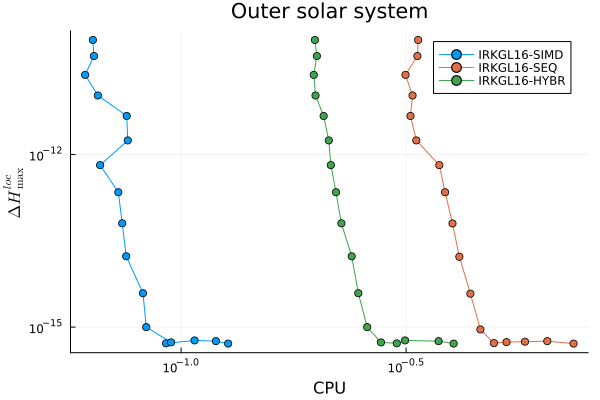

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [17]:
#
sols2plot=[sols_irk16_simd, sols_irk16_seq, sols_irk16_hyb]
labels2plot=["IRKGL16-SIMD", "IRKGL16-SEQ", "IRKGL16-HYBR"]

pl_=plot(title="Outer solar system", xlabel="CPU", ylabel=L"\Delta H^{loc}_{\mathrm{max}}",
          scale=:log10)

for i in 1:length(sols2plot)
    sols=sols2plot[i]
    plot!(pl_, sols.cpus , sols.MaxΔHlocal, markershape=:circle, label=labels2plot[i])
end
display(pl_)

<a href="#top">Back to the top</a>

## 2nd order explicit symplectic integrations

In [18]:
ddt0_split=vcat([2.,4.,6.,8.,10.],[12.,14.,16.,18.],collect(20.:5:80));

### flows seq

In [19]:
flows=[flowH1Nbody!, flowH2Nbody!]
prob_split_seq=SplittingProblem(flows, u0, tspan, Gm)

HAM=NbodyEnergy
@show(HAM(u0,Gm))

HAM(u0, Gm) = -9.522620605966966e-12


-9.522620605966966e-12

#### Composition methods

In [20]:
println("Strang: s=1")
s=1; r=2
alg=Splitting_alg(r=r, rkn=false)
sols_split_r2=run_many_Splitting(s, r, alg, prob_split_seq, ddt0_split, HAM, wcpu=false)

println("SUZ90: s=5")
s=5; r=4
alg=Splitting_alg(r=r, rkn=false)
sols_split_r4=run_many_Splitting(s, r, alg, prob_split_seq, s*ddt0_split, HAM, wcpu=false)

println("SS05: s=13")
s=13; r=6
alg=Splitting_alg(r=r, rkn=false)
sols_split_r6=run_many_Splitting(s, r, alg, prob_split_seq, s*ddt0_split, HAM, wcpu=false)

println("SS05: s=21")
s=21; r=8
alg=Splitting_alg(r=r, rkn=false)
sols_split_r8=run_many_Splitting(s, r, alg, prob_split_seq, s*ddt0_split, HAM, wcpu=true)

println("SS05: s=35")
s=35; r=10
alg=Splitting_alg(r=r, rkn=false)
sols_split_r10=run_many_Splitting(s, r, alg, prob_split_seq, s*ddt0_split, HAM, wcpu=false);


Strang: s=1
,2.0,4.0,6.0,8.0,10.0,12.0,14.0,16.0,18.0,20.0,25.0,30.0,35.0,40.0,45.0,50.0,55.0,60.0,65.0,70.0,75.0,80.0
SUZ90: s=5
,10.0,20.0,30.0,40.0,50.0,60.0,70.0,80.0,90.0,100.0,125.0,150.0,175.0,200.0,225.0,250.0,275.0,300.0,325.0,350.0,375.0,400.0
SS05: s=13
,26.0,52.0,78.0,104.0,130.0,156.0,182.0,208.0,234.0,260.0,325.0,390.0,455.0,520.0,585.0,650.0,715.0,780.0,845.0,910.0,975.0,1040.0
SS05: s=21
,42.0,84.0,126.0,168.0,210.0,252.0,294.0,336.0,378.0,420.0,525.0,630.0,735.0,840.0,945.0,1050.0,1155.0,1260.0,1365.0,1470.0,1575.0,1680.0
SS05: s=35
,70.0,140.0,210.0,280.0,350.0,420.0,490.0,560.0,630.0,700.0,875.0,1050.0,1225.0,1400.0,1575.0,1750.0,1925.0,2100.0,2275.0,2450.0,2625.0,2800.0


#### RKN symplectic integrations

In [21]:
println("BM02: s=14")
s=14; r=6
alg=Splitting_alg(r=r, rkn=true)
sols_split_rkn6=run_many_Splitting(s, r, alg, prob_split_seq, s*ddt0_split, HAM, wcpu=true)
#
println("BCE22: s=19")
s=19; r=8; rkn=true
alg=Splitting_alg(r=r, rkn=true)
sols_split_rkn8=run_many_Splitting(s, r, alg, prob_split_seq, s*ddt0_split, HAM, wcpu=true);

BM02: s=14
,28.0,56.0,84.0,112.0,140.0,168.0,196.0,224.0,252.0,280.0,350.0,420.0,490.0,560.0,630.0,700.0,770.0,840.0,910.0,980.0,1050.0,1120.0
BCE22: s=19
,38.0,76.0,114.0,152.0,190.0,228.0,266.0,304.0,342.0,380.0,475.0,570.0,665.0,760.0,855.0,950.0,1045.0,1140.0,1235.0,1330.0,1425.0,1520.0


### flows simd

In [22]:
flows_simd=[flowH1Nbody_simd!, flowH2Nbody_simd!]
prob_split_simd=SplittingProblem(flows_simd, u0_array, tspan, Gm)

HAM_array=NbodyEnergy_array
@show(HAM_array(u0_array,Gm))

HAM(u0_array, Gm) = -9.522620605966966e-12


-9.522620605966966e-12

#### Composition methods

In [23]:
#=
println("Strang: s=1")
s=1; r=2
alg=Splitting_alg(r=r, rkn=false)
sols_split_r2_simd=run_many_Splitting(s, alg, prob_split_simd, ddt0_split, HAM_array, wcpu=false)
=#

#=
println("SUZ90: s=5")
s=5; r=4
alg=Splitting_alg(r=r, rkn=false)
sols_split_r4_simd=run_many_Splitting(s, alg, prob_split_simd, s*ddt0_split, HAM_array, wcpu=false)
=#

#=
println("SS05: s=13")
s=13; r=6
alg=Splitting_alg(r=r, rkn=false)
sols_split_r6_simd=run_many_Splitting(s, alg, prob_split_simd, s*ddt0_split, HAM_array, wcpu=false)
=#
#
println("SS05: s=21")
s=21; r=8
alg=Splitting_alg(r=r, rkn=false)
sols_split_r8_simd=run_many_Splitting(s, r, alg, prob_split_simd, s*ddt0_split, HAM_array, wcpu=true)
#

#=
println("SS05: s=35")
s=35; r=10
alg=Splitting_alg(r=r, rkn=false)
sols_split_r10_simd=run_many_Splitting(s, alg, prob_split_simd, s*ddt0_split, HAM_array, wcpu=false);
=#;

SS05: s=21
,42.0,84.0,126.0,168.0,210.0,252.0,294.0,336.0,378.0,420.0,525.0,630.0,735.0,840.0,945.0,1050.0,1155.0,1260.0,1365.0,1470.0,1575.0,1680.0


#### RKN symplectic integrations

In [93]:
println("BM02: s=14")
s=14; r=6
alg=Splitting_alg(r=r, rkn=true)
sols_split_rkn6_simd=run_many_Splitting(s, r, alg, prob_split_simd, s*ddt0_split, HAM_array, wcpu=true)
#
println("BCE22: s=19")
s=19; r=8; rkn=true
alg=Splitting_alg(r=r, rkn=true)
sols_split_rkn8_simd=run_many_Splitting(s, r, alg, prob_split_simd, s*ddt0_split, HAM_array, wcpu=true);

BM02: s=14
,28.0,56.0,84.0,112.0,140.0,168.0,196.0,224.0,252.0,280.0,350.0,420.0,490.0,560.0,630.0,700.0,770.0,840.0,910.0,980.0,1050.0,1120.0
BCE22: s=19
,38.0,76.0,114.0,152.0,190.0,228.0,266.0,304.0,342.0,380.0,475.0,570.0,665.0,760.0,855.0,950.0,1045.0,1140.0,1235.0,1330.0,1425.0,1520.0


<a href="#top">Back to the top</a>

## Benchmarks diagrams


In [94]:

sols2plot=[sols_irk16_simd, sols_irk16_seq, sols_irk16_hyb,
           sols_split_r2, sols_split_r4, sols_split_r6, sols_split_r8, sols_split_r10,
           sols_split_rkn6, sols_split_rkn8]


labels2plot=["IRKGL16-SIMD", "IRKGL16-SEQ", "IRKGL16-HYBR",
              "Strang(r=2)", "SUZ90(r=4)", "SS05(r=6)", "SS05(r=8)", "SS05(r=10)", 
              "BM02(rkn6)", "BCE22(rkn8)" ]


colors2plot = [:red, :blue, :green,
               :orange, :purple, :cyan, :magenta, :teal,
               :gold, :gray];


### Work-precision diagrams

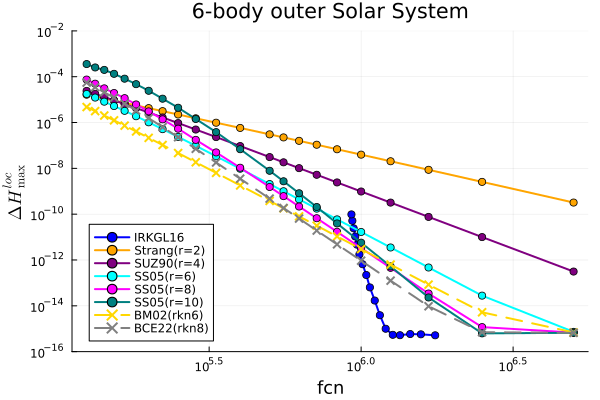

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [95]:
yrange=(1e-16, 1e-2)

sols=sols2plot[1]

pl3=plot(sols.fcns , sols.MaxΔHlocal, scale=:log10,
         markershape=:circle, lw=2,
         ylimits=yrange,    
         label="IRKGL16", color=colors2plot[2],
         title="6-body outer Solar System", 
         xlabel="fcn", ylabel=L"\Delta H^{loc}_{\mathrm{max}}",
         legend=:bottomleft,
         guidefont=font(12), labelsize=10)


for i in 4:length(sols2plot)
       
   sols=sols2plot[i]
    
   if occursin("rkn", labels2plot[i])
       plot!(pl3, sols.fcns , sols.MaxΔHlocal, 
       markershape=:xcross, lw=2, ls=:dash,
       label=labels2plot[i], color=colors2plot[i],
       scale=:log10)
        
   else 
       plot!(pl3, sols.fcns , sols.MaxΔHlocal, 
             markershape=:circle, lw=2,
             label=labels2plot[i], color=colors2plot[i],
             scale=:log10)
   end

end

display(pl3)

In [96]:
savefig("./figures/Fig7.pdf")

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


"/home/mikel/Nextcloud/Gure taldea (Ehu box)/IRKGL-2025/6-Splitting-metodoak/Splitting Solvers Implementation/Experiments_Article_2026/5-3- Numerical comprarisons of IRKGL16 with explicit symplectic integrators/figures/Fig7.pdf"

### Select splitting integration with same CPU-time

#### Flow-seq case

In [97]:
sols=sols2plot[1]
@show labels2plot[1]
[sols.MaxΔHlocal sols.cpus]

labels2plot[1] = "IRKGL16-SIMD"


17×2 Matrix{Float64}:
 5.17101e-16  0.127228
 5.70259e-16  0.119482
 5.86806e-16  0.107122
 5.21803e-16  0.0926039
 5.42583e-16  0.0949817
 9.99329e-16  0.0836592
 3.88306e-15  0.0822822
 1.70039e-14  0.0755213
 6.3674e-14   0.0739866
 2.20817e-13  0.0725313
 6.53317e-13  0.0660782
 1.75548e-12  0.0761263
 4.67331e-12  0.0757024
 1.06013e-11  0.0653231
 2.41753e-11  0.0612024
 5.13837e-11  0.0640183
 9.77403e-11  0.0636766

In [98]:
HAM=NbodyEnergy

index0=3   # IRKGL16: h=16, index0 (exact solution)
idx=8      # IRKGL16: index1 MaxΔHlocal~10^(-14)

index=[idx]
compute_index_ge_cpu!(index, sols_irk16_simd.cpus[idx], sols2plot[2:end])

println("Checking CPU times")

for i in 1:length(index)
    
    k=index[i]
    if sols2plot[i].wcpu
       sols2plot[i].cpu_idx=k
       println(k, " , ", labels2plot[i], " , ", sols2plot[i].dts[k], " , ", sols2plot[i].cpus[k], " , ", sols2plot[i].MaxΔHlocal[k])
    end
    
end

Checking CPU times
8 , IRKGL16-SIMD , 550.0 , 0.075521291 , 1.700385550655626e-14
17 , IRKGL16-SEQ , 1000.0 , 0.336414564 , 9.773992548356525e-11
17 , IRKGL16-HYBR , 1000.0 , 0.198285831 , 9.774033685664348e-11
8 , SS05(r=8) , 336.0 , 0.07611549 , 2.1555611926006524e-10
8 , BM02(rkn6) , 224.0 , 0.075963185 , 7.990873584508903e-11
8 , BCE22(rkn8) , 304.0 , 0.083573317 , 6.433918539708041e-11


#### Adjust step-size for splitting integrations

In [99]:
IRKGL16_cpu=sols2plot[1].cpus[idx]

0.075521291

##### Strangr2

In [100]:
#=
idx_met=4
idx_dt=index[idx_met]
method=sols2plot[idx_met]
println([sols2plot[1].cpus[idx]  labels2plot[idx_met] method.dts[idx_dt] method.cpus[idx_dt] ])

if method.wcpu
    h1=method.dts[idx_dt]
    T1=method.cpus[idx_dt] 
    T2=IRKGL16_cpu
     h2=floor(h1*T1/T2*0.95)

    s=method.s; r=method.r
    println(labels2plot[idx_met],",r=",r,",s=",s)
    alg=Splitting_alg(r=r, rkn=false)
    strangr2=run_many_Splitting(s, r, alg, prob_split_seq, [h2], HAM, wcpu=true)
    println([sols2plot[1].cpus[idx]  labels2plot[idx_met] strangr2.dts strangr2.cpus strangr2.MaxΔHlocal])
end
=#

##### SUZ90r4

In [101]:
#=

idx_met=5
idx_dt=index[idx_met]
method=sols2plot[idx_met]
println([sols2plot[1].cpus[idx]  labels2plot[idx_met] method.dts[idx_dt] method.cpus[idx_dt] ])

if method.wcpu
    h1=method.dts[idx_dt]
    T1=method.cpus[idx_dt] 
    T2=IRKGL16_cpu
     h2=floor(h1*T1/T2*0.95) 

    s=method.s; r=method.r
    println(labels2plot[idx_met],",r=",r,",s=",s)
    alg=Splitting_alg(r=r, rkn=false)
    suz90r4=run_many_Splitting(s, r, alg, prob_split_seq, [h2], HAM, wcpu=true)
    println([sols2plot[1].cpus[idx]  labels2plot[idx_met] suz90r4.dts suz90r4.cpus suz90r4.MaxΔHlocal])
end
=#

##### SS05r6

In [102]:
#=

idx_met=6
idx_dt=index[idx_met]
method=sols2plot[idx_met]
println([sols2plot[1].cpus[idx]  labels2plot[idx_met] method.dts[idx_dt] method.cpus[idx_dt] ] )

if method.wcpu
    h1=method.dts[idx_dt]
    T1=method.cpus[idx_dt] 
    T2=IRKGL16_cpu
    h2=floor(h1*T1/T2*0.95) 

    s=method.s; r=method.r
    println(labels2plot[idx_met],",r=",r,",s=",s)
    alg=Splitting_alg(r=r, rkn=false)
    ss05r6=run_many_Splitting(s, r, alg, prob_split_seq, [h2], HAM, wcpu=true)
    println([sols2plot[1].cpus[idx]  labels2plot[idx_met] ss05r6.dts ss05r6.cpus ss05r6.MaxΔHlocal])
end
=#

##### SS05r8

In [103]:
idx_met=7 #4
idx_dt=index[idx_met]
method=sols2plot[idx_met]
println([sols2plot[1].cpus[idx]  labels2plot[idx_met] method.dts[idx_dt] method.cpus[idx_dt] ])

if method.wcpu
    h1=method.dts[idx_dt]
    T1=method.cpus[idx_dt] 
    T2=IRKGL16_cpu
    h2=floor(h1*T1/T2*0.95)
    h2=378.0

    s=method.s; r=method.r
    println(labels2plot[idx_met],",r=",r,",s=",s)
    alg=Splitting_alg(r=r, rkn=false)
    ss05r8=run_many_Splitting(s, r, alg, prob_split_seq, [h2], HAM, wcpu=true)
    println([sols2plot[1].cpus[idx]  labels2plot[idx_met] ss05r8.dts ss05r8.cpus ss05r8.MaxΔHlocal])

end

Any[0.075521291 "SS05(r=8)" 336.0 0.07611549]
SS05(r=8),r=8,s=21
,378.0
Any[0.075521291 "SS05(r=8)" 378.0 0.076562244 6.125623174144689e-10]


##### SS05r10

In [104]:
#=

idx_met=8
idx_dt=index[idx_met]
method=sols2plot[idx_met]
println([sols2plot[1].cpus[idx]  labels2plot[idx_met] method.dts[idx_dt] method.cpus[idx_dt] ]) 

if method.wcpu
    h1=method.dts[idx_dt]
    T1=method.cpus[idx_dt] 
    T2=IRKGL16_cpu
     h2=floor(h1*T1/T2*0.95)

    s=method.s; r=method.r
    println(labels2plot[idx_met],",r="m,r,",s=",s)
    alg=Splitting_alg(r=r, rkn=false)
    ss05r10=run_many_Splitting(s, alg, prob_split_seq, [h2], HAM, wcpu=true)
    println([sols2plot[1].cpus[idx]  labels2plot[idx_met] ss05r10.dts ss05r10.cpus ss05r8.MaxΔHlocal])

end
=#

##### BM02r6

In [105]:
idx_met=9 #5
idx_dt=index[idx_met]
method=sols2plot[idx_met]
println([sols2plot[1].cpus[idx]  labels2plot[idx_met] method.dts[idx_dt] method.cpus[idx_dt] ] )

if method.wcpu
    h1=method.dts[idx_dt]
    T1=method.cpus[idx_dt] 
    T2=IRKGL16_cpu
    h2=floor(h1*T1/T2*0.95) 
    h2=224.0

    s=method.s; r=method.r
    println(labels2plot[idx_met],",r=",r,",s=",s)
    alg=Splitting_alg(r=r, rkn=true)
    bm02r6=run_many_Splitting(s,r, alg, prob_split_seq, [h2], HAM, wcpu=true)
    println([sols2plot[1].cpus[idx]  labels2plot[idx_met] bm02r6.dts bm02r6.cpus bm02r6.MaxΔHlocal])

end

Any[0.075521291 "BM02(rkn6)" 224.0 0.075963185]
BM02(rkn6),r=6,s=14
,224.0
Any[0.075521291 "BM02(rkn6)" 224.0 0.089255411 7.990873584508903e-11]


##### BCE22

In [106]:
idx_met=10 #6
idx_dt=index[idx_met]
method=sols2plot[idx_met]
println([sols2plot[1].cpus[idx]  labels2plot[idx_met] method.dts[idx_dt] method.cpus[idx_dt] ])

if method.wcpu
    h1=method.dts[idx_dt]
    T1=method.cpus[idx_dt] 
    T2=IRKGL16_cpu
     h2=floor(h1*T1/T2*1.05) 
    h2=300.0

    s=method.s; r=method.r
    println(labels2plot[idx_met],",r=",r,",s=",s)
    alg=Splitting_alg(r=r, rkn=true)
    bce22r8=run_many_Splitting(s, r, alg, prob_split_seq, [h2], HAM, wcpu=true)
    println([sols2plot[1].cpus[idx]  labels2plot[idx_met]  bce22r8.dts  bce22r8.cpus  bce22r8.MaxΔHlocal])

end

Any[0.075521291 "BCE22(rkn8)" 304.0 0.083573317]
BCE22(rkn8),r=8,s=19
,300.0
Any[0.075521291 "BCE22(rkn8)" 300.0 0.084547064 5.6811289002307313e-11]


#### Flow-simd case

In [107]:
#=
sols2plot_simd=[sols_irk16_simd, sols_irk16_seq, sols_irk16_hyb,
           sols_split_r2_simd, sols_split_r4_simd, sols_split_r6_simd, sols_split_r8_simd, sols_split_r10_simd,
           sols_split_rkn6_simd, sols_split_rkn8_simd]
=#

sols2plot_vec=[sols_irk16_simd, sols_irk16_seq, sols_irk16_hyb,
                sols_split_r8_simd, 
                sols_split_rkn6_simd, sols_split_rkn8_simd]

#=
labels2plot_simd=["IRKGL16-SIMD", "IRKGL16-SEQ", "IRKGL16-HYBR",
              "Strangr2_vec", "SUZ90r4_vec", "SS05r6_vec", "SS05r8_vec", "SS05r10_vec", 
              "BM02_vec", "BCE22_vec" ]
=#

labels2plot_vec=["IRKGL16-SIMD", "IRKGL16-SEQ", "IRKGL16-HYBR",
                  "SS05r8_vec", 
                  "BM02_vec", "BCE22_vec" ];

In [108]:
HAM=NbodyEnergy_array
index=[idx]
compute_index_ge_cpu!(index, sols_irk16_simd.cpus[idx], sols2plot_vec[2:end])

println("Checking CPU times")

for i in 1:length(index)
    
    k=index[i]
    if sols2plot_vec[i].wcpu
       sols2plot_vec[i].cpu_idx=k
       println(k, " , ", labels2plot_vec[i], " , ", sols2plot_vec[i].dts[k], " , ", sols2plot_vec[i].cpus[k], " , ", sols2plot_vec[i].MaxΔHlocal[k])
    end
    
end

Checking CPU times
8 , IRKGL16-SIMD , 550.0 , 0.075521291 , 1.700385550655626e-14
17 , IRKGL16-SEQ , 1000.0 , 0.336414564 , 9.773992548356525e-11
17 , IRKGL16-HYBR , 1000.0 , 0.198285831 , 9.774033685664348e-11
5 , SS05r8_vec , 210.0 , 0.082056239 , 3.3042629930810296e-12
5 , BM02_vec , 140.0 , 0.085803762 , 2.993674142796801e-12
5 , BCE22_vec , 190.0 , 0.083891665 , 9.33816876216048e-13


#### Adjust step-size for splitting integrations

##### SS05r8_vec

In [109]:
idx_met=4  #7
idx_dt=index[idx_met]
method=sols2plot_vec[idx_met]
println([sols2plot_vec[1].cpus[idx]  labels2plot_vec[idx_met] method.dts[idx_dt] method.cpus[idx_dt] ] )

if method.wcpu
    h1=method.dts[idx_dt]
    T1=method.cpus[idx_dt] 
    T2=IRKGL16_cpu
    @show h2=floor(h1*T1/T2) 
    h2=300.0

    s=method.s; r=method.r
    println(labels2plot_vec[idx_met],",r=",r,",s=",s)
    alg=Splitting_alg(r=r, rkn=false)
    ss05r8_vec=run_many_Splitting(s, r, alg, prob_split_simd, [h2], HAM, wcpu=true)
    println([sols2plot_vec[1].cpus[idx]  labels2plot_vec[idx_met] ss05r8_vec.dts ss05r8_vec.cpus ss05r8_vec.MaxΔHlocal] )
end

Any[0.075521291 "SS05r8_vec" 210.0 0.082056239]
h2 = floor((h1 * T1) / T2) = 228.0
SS05r8_vec,r=8,s=21
,300.0
Any[0.075521291 "SS05r8_vec" 300.0 0.05866923 7.929944383080883e-11]


##### BM02r6_vec

In [110]:
idx_met=5  #9
idx_dt=index[idx_met]
method=sols2plot_vec[idx_met]
println([sols2plot_vec[1].cpus[idx]  labels2plot_vec[idx_met] method.dts[idx_dt] method.cpus[idx_dt] ]) 

if method.wcpu
    h1=method.dts[idx_dt]
    T1=method.cpus[idx_dt] 
    T2=IRKGL16_cpu
    h2=floor(h1*T1/T2) 
    h2=145.0

    s=method.s; r=method.r
    println(labels2plot_vec[idx_met],",r=",r,",s=",s)
    alg=Splitting_alg(r=r, rkn=true)
    bm02r6_vec=run_many_Splitting(s, r, alg, prob_split_simd, [h2], HAM, wcpu=true)
    println([sols2plot_vec[1].cpus[idx]  labels2plot_vec[idx_met] bm02r6_vec.dts bm02r6_vec.cpus bm02r6_vec.MaxΔHlocal] )
end

Any[0.075521291 "BM02_vec" 140.0 0.085803762]
BM02_vec,r=6,s=14
,145.0
Any[0.075521291 "BM02_vec" 145.0 0.095935056 3.828336733193555e-12]


##### BCE22r8_vec

In [111]:
idx_met=6  #10
idx_dt=index[idx_met]
method=sols2plot_vec[idx_met]
println([sols2plot_vec[1].cpus[idx]  labels2plot_vec[idx_met] method.dts[idx_dt] method.cpus[idx_dt] ] )

if method.wcpu
    h1=method.dts[idx_dt]
    T1=method.cpus[idx_dt] 
    T2=IRKGL16_cpu
    h2=floor(h1*T1/T2)

    s=method.s; r=method.r
    println(labels2plot_vec[idx_met],",r=",r,",s=",s)
    alg=Splitting_alg(r=r, rkn=true)
    bce22r8_vec=run_many_Splitting(s, r, alg, prob_split_simd, [h2], HAM, wcpu=true)
    println([sols2plot_vec[1].cpus[idx]  labels2plot_vec[idx_met] bce22r8_vec.dts bce22r8_vec.cpus bce22r8_vec.MaxΔHlocal] )
end

Any[0.075521291 "BCE22_vec" 190.0 0.083891665]
BCE22_vec,r=8,s=19
,211.0
Any[0.075521291 "BCE22_vec" 211.0 0.087726334 2.3972327796121934e-12]


#### Working-precision diagrams (cpu)

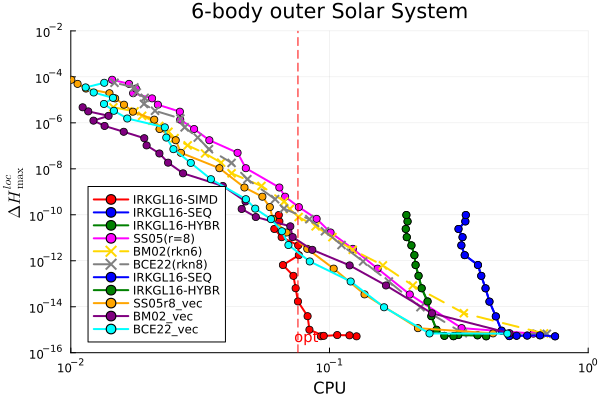

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [112]:
yrange=(1e-16, 1e-2)
xrange=(1e-2,1e0)

sols=sols_irk16_simd
pl1=plot( sols.cpus , sols.MaxΔHlocal, scale=:log10,
          markershape=:circle, lw=2,
          ylimits=yrange, xlimits=xrange,
          label=labels2plot[1], color=colors2plot[1],
          legend=:bottomleft,
           title="6-body outer Solar System",  xlabel="CPU", ylabel=L"\Delta H^{loc}_{\mathrm{max}}")

for i in 2:length(sols2plot)
    
    sols=sols2plot[i]

    if sols.wcpu
        if occursin("rkn", labels2plot[i])
            
            plot!(pl1, sols.cpus , sols.MaxΔHlocal, 
            markershape=:xcross, lw=2, ls=:dash,
            label=labels2plot[i], color=colors2plot[i],
            scale=:log10)
        
        else
            plot!(pl1, sols.cpus , sols.MaxΔHlocal, 
            markershape=:circle, lw=2,
            label=labels2plot[i], color=colors2plot[i],
            scale=:log10)
        end
    end
    
end

for i in 2:length(sols2plot_vec)
    
    sols=sols2plot_vec[i]

    if sols.wcpu
        if occursin("rkn", labels2plot_vec[i])
            
            plot!(pl1, sols.cpus , sols.MaxΔHlocal, 
            markershape=:xcross, lw=2, ls=:dash,
            label=labels2plot_vec[i], color=colors2plot[i],
            scale=:log10)
        
        else
            plot!(pl1, sols.cpus , sols.MaxΔHlocal, 
            markershape=:circle, lw=2,
            label=labels2plot_vec[i], color=colors2plot[i],
            scale=:log10)
        end
    end
    
end

vline!(pl1, [sols_irk16_simd.cpus[index[1]]], line=:dash, label="", color=:red)
annotate!((sols_irk16_simd.cpus[index[1]]+0.38, 0.05), text("opt", :red, 10, :center))

#### Resume

In [113]:
# simd
i=1
idx=index[i] #sols2plot[i].cpu_idx
cpu=sols2plot[i].cpus[idx]
fcn=sols2plot[i].fcns[idx]
cpu_fcn_simd=cpu/fcn
# seq
i=2
idx=index[i] #sols2plot[i].cpu_idx
cpu=sols2plot[i].cpus[idx]
fcn=sols2plot[i].fcns[idx]
cpu_fcn_seq=cpu/fcn
# hybr
i=3
idx=index[i] #sols2plot[i].cpu_idx
cpu=sols2plot[i].cpus[idx]
fcn=sols2plot[i].fcns[idx]
cpu_fcn_hybr=cpu/fcn

## Flow-seq #########################
#####################################

cpu=ss05r8.cpus[1]
fcn=ss05r8.fcns[1]
MaxΔHlocal=ss05r8.MaxΔHlocal[1]
cpu_fcn3=cpu_fcn_simd/(cpu/fcn)

cpu_fcn1=cpu_fcn_seq/(cpu/fcn)

cpu_fcn2=cpu_fcn_hybr/(cpu/fcn)

println("SS05r8_seq dt=", ss05r8.dts[1], ",IRKGL16-SIMD=", sols2plot[1].dts[1])
println("SS05r8_seq", ",seq=", cpu_fcn1, ",hybr=", cpu_fcn2, ",simd=", cpu_fcn3)
println("MaxΔHlocal", ",seq=", nothing, ",hybr=", nothing, ",simd=", MaxΔHlocal)
println("cpu/fcn_spl=",cpu/fcn) 
println("cpu/fcn",    ",seq=", cpu_fcn_seq, ",hybr=", cpu_fcn_hybr, ",simd=",cpu_fcn_simd)

#####################################

#=
cpu=bm02r6.cpus[1]
fcn=bm02r6.fcns[1]
MaxΔHlocal=bm02r6.MaxΔHlocal[1]
cpu_fcn3=cpu_fcn_simd/(cpu/fcn)

cpu_fcn1=cpu_fcn_seq/(cpu/fcn)

cpu_fcn2=cpu_fcn_hybr/(cpu/fcn)


println("BM02_seq", ",seq=", cpu_fcn1, ",hybr=", cpu_fcn2, ",simd=", cpu_fcn3)
println("MaxΔHlocal", ",seq=", nothing, ",hybr=", nothing, ",simd=", MaxΔHlocal)

#####################################

cpu=bce22r8.cpus[1]
fcn=bce22r8.fcns[1]
MaxΔHlocal=bce22r8.MaxΔHlocal[1]
cpu_fcn3=cpu_fcn_simd/(cpu/fcn)

cpu_fcn1=cpu_fcn_seq/(cpu/fcn)

cpu_fcn2=cpu_fcn_hybr/(cpu/fcn)


println("BCE22_seq", ",seq=", cpu_fcn1, ",hybr=", cpu_fcn2, ",simd=", cpu_fcn3)
println("MaxΔHlocal", ",seq=", nothing, ",hybr=", nothing, ",simd=", MaxΔHlocal)

=#

## Flow-simd #########################
#####################################

cpu=ss05r8_vec.cpus[1]
fcn=ss05r8_vec.fcns[1]
MaxΔHlocal=ss05r8_vec.MaxΔHlocal[1]
cpu_fcn3=cpu_fcn_simd/(cpu/fcn)

cpu_fcn1=cpu_fcn_seq/(cpu/fcn)

cpu_fcn2=cpu_fcn_hybr/(cpu/fcn)

println("")

println("SS05r8_vec dt=", ss05r8_vec.dts[1], ",IRKGL16-SIMD=", sols2plot[1].dts[1])
println("SS05r8_vec", ",seq=", cpu_fcn1, ",hybr=", cpu_fcn2, ",simd=", cpu_fcn3)
println("MaxΔHlocal", ",seq=", nothing, ",hybr=", nothing, ",simd=", MaxΔHlocal)
println("cpu/fcn_spl=",cpu/fcn) 
println("SS05r8_vec", ",seq=", cpu_fcn_seq, ",hybr=", cpu_fcn_hybr, ",simd=", cpu_fcn_simd)

#####################################

#=

cpu=bm02r6_vec.cpus[1]
fcn=bm02r6_vec.fcns[1]
MaxΔHlocal=bm02r6_vec.MaxΔHlocal[1]
cpu_fcn3=cpu_fcn_simd/(cpu/fcn)

cpu_fcn1=cpu_fcn_seq/(cpu/fcn)

cpu_fcn2=cpu_fcn_hybr/(cpu/fcn)


println("BM02_simd", ",seq=", cpu_fcn1, ",hybr=", cpu_fcn2, ",simd=", cpu_fcn3)
println("MaxΔHlocal", ",seq=", nothing, ",hybr=", nothing, ",simd=", MaxΔHlocal)

#####################################

cpu=bce22r8_vec.cpus[1]
fcn=bce22r8_vec.fcns[1]
MaxΔHlocal=bce22r8_vec.MaxΔHlocal[1]
cpu_fcn3=cpu_fcn_simd/(cpu/fcn)

cpu_fcn1=cpu_fcn_seq/(cpu/fcn)

cpu_fcn2=cpu_fcn_hybr/(cpu/fcn)


println("BCE22_simd", ",seq=", cpu_fcn1, ",hybr=", cpu_fcn2, ",simd=", cpu_fcn3)
println("MaxΔHlocal", ",seq=", nothing, ",hybr=", nothing, ",simd=", MaxΔHlocal)

=#



SS05r8_seq dt=378.0,IRKGL16-SIMD=200.0
SS05r8_seq,seq=2.5999214096469765,hybr=1.548433677287054,simd=0.49428376535485063
MaxΔHlocal,seq=nothing,hybr=nothing,simd=6.125623174144689e-10
cpu/fcn_spl=1.3780696790358116e-7
cpu/fcn,seq=3.582872862510544e-7,hybr=2.133849500667212e-7,simd=6.811574698751714e-8

SS05r8_vec dt=300.0,IRKGL16-SIMD=200.0
SS05r8_vec,seq=4.274917472033391,hybr=2.546010105058576,simd=0.8127254527069782
MaxΔHlocal,seq=nothing,hybr=nothing,simd=7.929944383080883e-11
cpu/fcn_spl=8.381150948409603e-8
SS05r8_vec,seq=3.582872862510544e-7,hybr=2.133849500667212e-7,simd=6.811574698751714e-8


<a href="#top">Back to the top</a>

### Error in Energy

In [114]:
methods2plot=[sols_irk16_simd,
              ss05r8, bm02r6, bce22r8,
              ss05r8_vec, bm02r6_vec, bce22r8_vec
            ]


labels2plot_=["IRKGL16-SIMD", 
              "SS05r8", "BM02", "BCE22",
              "SS05r8_vec", "BM02_vec", "BCE22_vec"
            ]

colors2plot_ = [:red, 
                :magenta,  :gold, :gray,
                :magenta,  :gold, :gray    
    ];


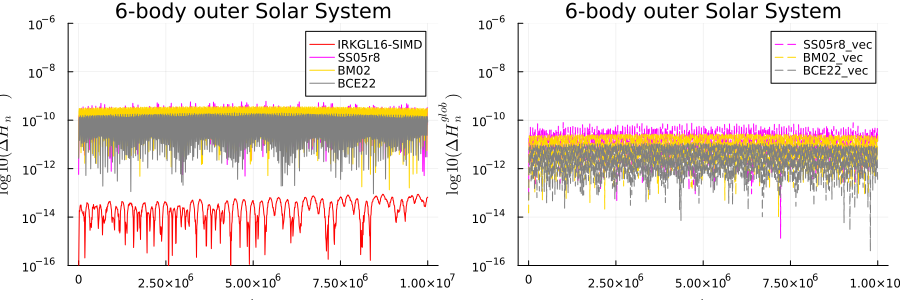

In [115]:
yrange=(1e-16, 1e-6)

pl3=plot(title="6-body outer Solar System",
         xlabel="t", ylabel=L"\log10(\Delta H^{glob}_n)",
         ylimits=yrange, yscale=:log10, legend=:topright)

HAM=NbodyEnergy
H0=HAM(u0_B,Gm_B)
H = [HAM(BigFloat.(u),Gm_B) for u in sols_irk16_simd.sols[index[1]].u]
ΔH0 = @. Float64(abs(H/H0-1))

m0 = max(1,div(Int64(ceil((tF-t0)/ddt0_irk16[index[1]])),1000))

plot!(pl3,sols_irk16_simd.sols[index[1]].t[2:m0:end], abs.(ΔH0[2:m0:end]),
        label=labels2plot_[1],color=colors2plot_[1])


# splitting

for k in 2:4 #length(methods2plot)

    if methods2plot[k].wcpu
        #idx=methods2plot[k].cpu_idx
        idx=1
        solk=methods2plot[k].sols[idx]
        dt_split=methods2plot[k].dts[idx]
        m0 = max(1,div(Int64(ceil((tF-t0)/dt_split)),1000))
        labelk=labels2plot_[k]
        colork=colors2plot_[k]
        
        H = [HAM(BigFloat.(u),Gm_B) for u in solk.u]
        ΔH0 = @. Float64(abs(H/H0-1))
        plot!(pl3, solk.t[2:m0:end], abs.(ΔH0[2:m0:end]), yscale=:log10,
              label=labelk, color=colork)

    end
end


pl4=plot(title="6-body outer Solar System",
         xlabel="t", ylabel=L"\log10(\Delta H^{glob}_n)",
         ylimits=yrange, yscale=:log10, legend=:topright)

HAM=NbodyEnergy_array
for k in 5:7 #length(methods2plot)

    if methods2plot[k].wcpu
        #idx=methods2plot[k].cpu_idx
        idx=1
        solk=methods2plot[k].sols[idx]
        dt_split=methods2plot[k].dts[idx]
        m0 = max(1,div(Int64(ceil((tF-t0)/dt_split)),1000))
        labelk=labels2plot_[k]
        colork=colors2plot_[k]
        
        H = [HAM(BigFloat.(u),Gm_B) for u in solk.u]
        ΔH0 = @. Float64(abs(H/H0-1))
        plot!(pl4, solk.t[2:m0:end], abs.(ΔH0[2:m0:end]), yscale=:log10, 
            ls=:dash,
            label=labelk, color=colork)

    end
end

plot(pl3)

plot(pl3, pl4, layout=(1,2), size=(900,300))

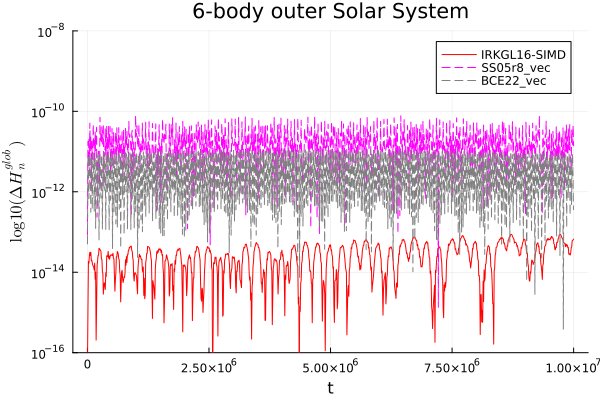

In [116]:
yrange=(1e-16, 1e-8)

pl5=plot(title="6-body outer Solar System",
         xlabel="t", ylabel=L"\log10(\Delta H^{glob}_n)",
         ylimits=yrange, yscale=:log10, legend=:topright)

HAM=NbodyEnergy
H0=HAM(u0_B,Gm_B)
H = [HAM(BigFloat.(u),Gm_B) for u in sols_irk16_simd.sols[index[1]].u]
ΔH0 = @. Float64(abs(H/H0-1))

m0 = max(1,div(Int64(ceil((tF-t0)/ddt0_irk16[index[1]])),1000))

plot!(pl5,sols_irk16_simd.sols[index[1]].t[2:m0:end], abs.(ΔH0[2:m0:end]),
        label=labels2plot_[1],color=colors2plot_[1])


# splitting vec


HAM=NbodyEnergy_array
for k in 5:7 #length(methods2plot)

    if k !=6 
        
        if methods2plot[k].wcpu
            #idx=methods2plot[k].cpu_idx
            idx=1
            solk=methods2plot[k].sols[idx]
            dt_split=methods2plot[k].dts[idx]
            m0 = max(1,div(Int64(ceil((tF-t0)/dt_split)),1000))
            labelk=labels2plot_[k]
            colork=colors2plot_[k]
            
            H = [HAM(BigFloat.(u),Gm_B) for u in solk.u]
            ΔH0 = @. Float64(abs(H/H0-1))
            plot!(pl5, solk.t[2:m0:end], abs.(ΔH0[2:m0:end]), yscale=:log10, 
                ls=:dash,
                label=labelk, color=colork)
    
        end
    end
    
end

plot(pl5)


In [117]:
savefig("./figures/Fig14.pdf")

"/home/mikel/Nextcloud/Gure taldea (Ehu box)/IRKGL-2025/6-Splitting-metodoak/Splitting Solvers Implementation/Experiments_Article_2026/5-3- Numerical comprarisons of IRKGL16 with explicit symplectic integrators/figures/Fig14.pdf"

<a href="#top">Back to the top</a>

### Error in Solution

In [118]:
methods2plot=[sols_irk16_simd, 
              ss05r8, bm02r6, bce22r8,
              ss05r8_vec, bm02r6_vec, bce22r8_vec
]


labels2plot_er=["IRKGL16-SIMD",  
                "SS05r8", "BM02", "BCE22",
                "SS05r8_vec", "BM02_vec", "BCE22_vec"
] 


colors2plot_er=[:red, 
                :teal, :gold, :gray,
                :teal, :gold, :gray
    ];


In [119]:
yrange=(1e-16, 1e-2)

qerr=Array{Array{Float64,1}}(undef,N)
ploterr = Vector{Plots.Plot}(undef, length(methods2plot))
dim=3

for k in 1:length(methods2plot)

    if methods2plot[k].wcpu

        #idx=methods2plot[k].cpu_idx
        idx=1
        errors2plot=methods2plot[k].sols[idx]
        ddt02plot=methods2plot[k].dts[idx]
        
        w=lcm_floats_vector(vcat(ddt0_irk16[index0],ddt02plot))
        ii=Int64.(w./(vcat(ddt0_irk16[index0],ddt02plot))).+1
        
        v0=sols_irk16_simd.sols[index0].t[ii[1]:ii[1]-1:3*ii[1]] 
        v1=errors2plot.t[ii[2]:ii[2]-1:3*ii[2]]
        
        println("k=", k, ",",labels2plot_er[k],",", v0 )
        println("k=", k, ",",labels2plot_er[k],",", v1 )
        println("*****************************")
        
        
         ploterr[k]=plot(title=string("6-body outer Solar System - ",labels2plot_er[k]),
                 ylims=yrange,
                 yscale=:log10,
                 xlabel="t (years)",
                 ylabel="error in position", label="") 
    
        if k<=4 
            for i in 1:N
                qerr[i]=map((u0,u1)-> (norm(BigFloat.(u0[:,i,1])-BigFloat.(u1[:,i,1]))/norm(BigFloat.(u0[:,i,1]))), 
                             sols_irk16_simd.sols[index0].u[ii[1]:ii[1]-1:end], errors2plot.u[ii[2]:ii[2]-1:end])
            end

        else #nbody_Array
            for i in 1:N
                iq=(i-1)*dim
                qerr[i]=map((u0,u1)-> (norm(BigFloat.(u0[:,i,1])-BigFloat.(u1[iq+1:iq+3]))/norm(BigFloat.(u0[:,i,1]))), 
                             sols_irk16_simd.sols[index0].u[ii[1]:ii[1]-1:end], errors2plot.u[ii[2]:ii[2]-1:end])
            end

        end
          
    
        tt=errors2plot.t[ii[2]:ii[2]-1:end]
        
        if k==1
          plot!(ploterr[k], tt , qerr, label=bodylist)
        else       
          plot!(ploterr[k], tt , qerr, label=bodylist)
        end

    end
    
end



k=1,IRKGL16-SIMD,[600.0, 1200.0, 1800.0, 2400.0]
k=1,IRKGL16-SIMD,[600.0, 1200.0, 1800.0]
*****************************
k=2,SS05r8,[18900.0, 37800.0, 56700.0]
k=2,SS05r8,[18900.0, 37800.0, 56700.0]
*****************************
k=3,BM02,[16800.0, 33600.0, 50400.0]
k=3,BM02,[16800.0, 33600.0, 50400.0]
*****************************
k=4,BCE22,[300.0, 600.0, 900.0, 1200.0, 1500.0]
k=4,BCE22,[300.0, 600.0, 900.0, 1200.0, 1500.0]
*****************************
k=5,SS05r8_vec,[300.0, 600.0, 900.0, 1200.0, 1500.0]
k=5,SS05r8_vec,[300.0, 600.0, 900.0, 1200.0, 1500.0]
*****************************
k=6,BM02_vec,[8700.0, 17400.0, 26100.0]
k=6,BM02_vec,[8700.0, 17400.0, 26100.0]
*****************************
k=7,BCE22_vec,[63300.0, 126600.0, 189900.0]
k=7,BCE22_vec,[63300.0, 126600.0, 189900.0]
*****************************


In [120]:
yrange=(1e-16, 1e-2)

for k in 1:length(methods2plot)

    if methods2plot[k].wcpu
    
        if k==1
    
            plot(ploterr[k],
                 legend=:topright,
                 ylims=yrange,
                 yscale=:log10,
                 xlabel="t (years)",
                 ylabel="error in position")
           #  label=planets,legend=:topleft)
    
            savefig("./figures/Fig15.pdf")
            
        else
             plot(ploterr[k],
             legend=:bottomright,
             ylims=yrange,
             yscale=:log10,
             xlabel="t (years)",
             ylabel="error in position", label="")
           #  label=planets,legend=:topleft)
    
             if k==5 savefig("./figures/Fig16.pdf") end
           #  if k==6 savefig("./figures/Fig17-1.pdf") end
           #  if k==7 savefig("./figures/Fig17-2.pdf") end
            
        end

    end
    
    #savefig(string("./figures/Fig2d-", k, ".pdf"))
    
end

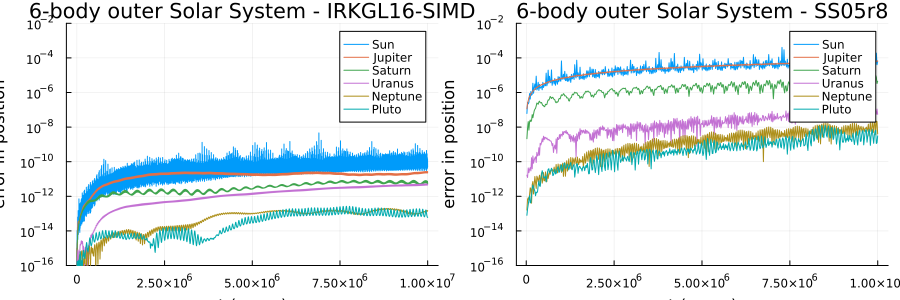

In [121]:
plot(ploterr[1], ploterr[2], layout=(1,2), size=(900,300))

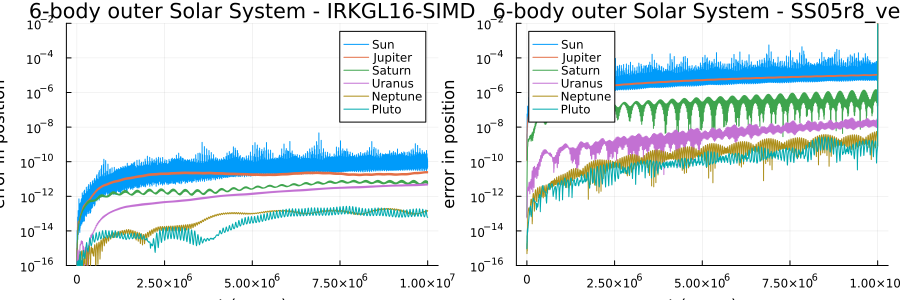

In [122]:
plot(ploterr[1], ploterr[5], layout=(1,2), size=(900,300))